# Configuración básica (no tocar)

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [112]:
x = Variable()

# Implementación de métodos

In [113]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    derf = f.derivative()
    
    for step in range(max_iter):
        m = (a + b) / 2
        
        fm = derf.eval(m)
        if fm == 0:
            return m, step + 1
        
        if derf.eval(a) * fm < 0:
            b = m
        else:
            a = m
        
        if (b - a) < tol:
            break
    
    return (a + b) / 2, step + 1

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    derf  = f.derivative()
    derdf = derf.derivative()
    
    xn = x0
    for step in range(max_iter):
        denom = derdf.eval(xn)
        xn = xn - derf.eval(xn) / denom
        
        if abs(derf.eval(xn)) < tol:
            break
    
    return xn, step + 1

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    derf = f.derivative()
    
    xn = x0
    for step in range(max_iter):
        grad = derf.eval(xn)
        xn = xn - lr * grad
        
        if abs(grad) < tol:
            break
    
    return xn, step + 1

### Prueba de métodos

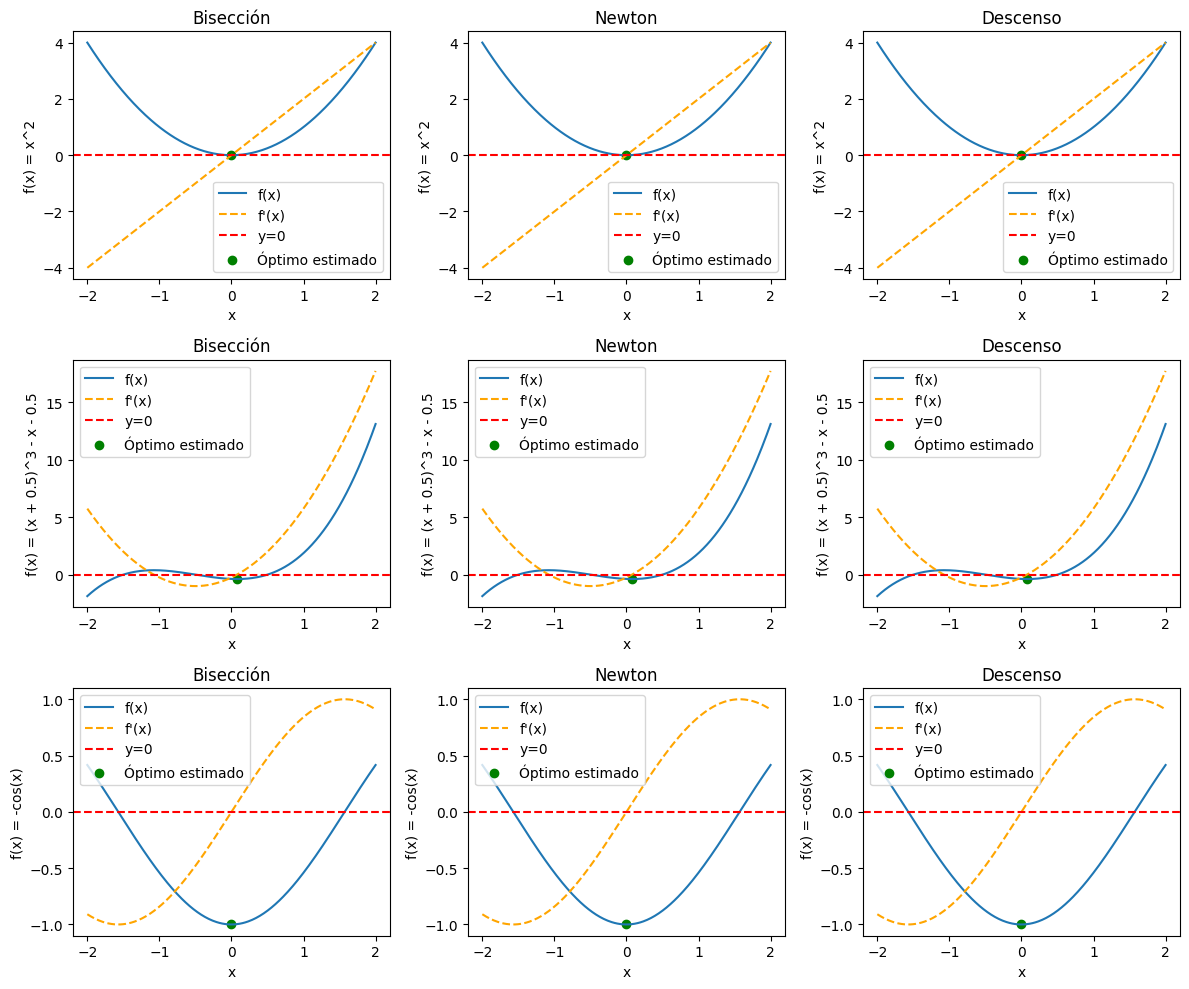

In [114]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.show()

# Aplicación a función no trivial

In [115]:
f = x**2 + 2*sin(3*x)

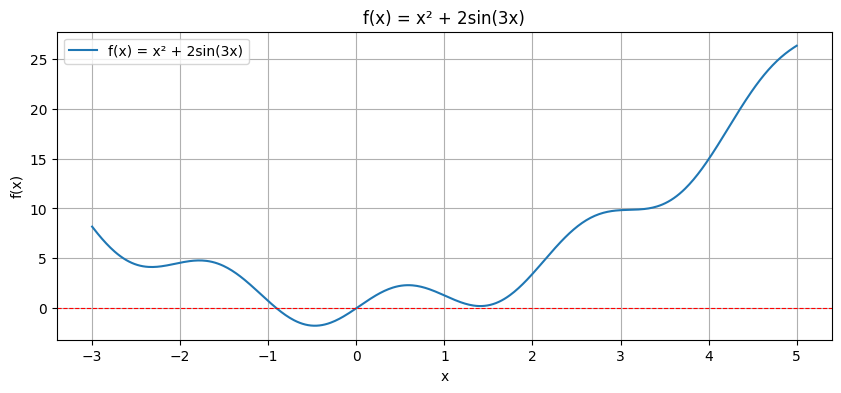

In [116]:
# Grafica de la función
lp = np.linspace(-3, 5, 500)
y_vals = np.array([f.eval(v) for v in lp])

plt.figure(figsize=(10, 4))
plt.plot(lp, y_vals, label="f(x) = x² + 2sin(3x)")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = x² + 2sin(3x)")
plt.legend()
plt.grid(True)
plt.show()

In [117]:
# Evaluación de métodos y generación de tablas
# Condiciones iniciales
biseccion_params = [
    {"a": -2, "b": 1},
    {"a": -1, "b": 0},
    {"a": 1,  "b": 2},
]

newton_params = [
    {"x0": -2},
    {"x0": -1},
    {"x0":  4},
]

gradiente_params = [
    {"x0": -3,     "lr": 0.01},
    {"x0": 0.585,  "lr": 0.01},
    {"x0": 4,      "lr": 0.01},
]

predicciones_biseccion = [
    "Mínimo cerca de x ≈ -0.5",
    "Mínimo cerca de x ≈ -0.5",
    "Máximo cerca de x ≈ 1.5",
]

predicciones_newton = [
    "Máximo cerca de x ≈ -1.8",
    "Mínimo cerca de x ≈ -0.5",
    "Diverge (se aleja hacia infinito)",
]

predicciones_gradiente = [
    "Mínimo cerca de x ≈ -2.5",
    "Mínimo cerca de x ≈ -0.5",
    "Mínimo cerca de x ≈ 1.5",
]

rows = []

for params, pred in zip(biseccion_params, predicciones_biseccion):
    res, steps = biseccion(f, **params)
    rows.append({"Método": "Bisección", "Condición inicial": str(params), "Predicción": pred, "Resultado": round(res, 4), "Iteraciones": steps})

for params, pred in zip(newton_params, predicciones_newton):
    res, steps = newton(f, **params)
    rows.append({"Método": "Newton", "Condición inicial": str(params), "Predicción": pred, "Resultado": round(res, 4), "Iteraciones": steps})

for params, pred in zip(gradiente_params, predicciones_gradiente):
    res, steps = descenso_gradiente(f, **params)
    rows.append({"Método": "Gradiente", "Condición inicial": str(params), "Predicción": pred, "Resultado": round(res, 4), "Iteraciones": steps})

df_tabla = pd.DataFrame(rows)
display(df_tabla)

# Prueba de distintos learning rates
print("\n--- Efecto del learning rate en descenso por gradiente ---")
lrs = [0.001, 0.01, 0.1, 0.5]

rows_lr = []
for lr in lrs:
    for x0 in [-3, 0.585, 4]:
        res, steps = descenso_gradiente(f, x0=x0, lr=lr)
        rows_lr.append({
            "Learning rate": lr,
            "x0": x0,
            "Resultado": round(res, 4),
            "Iteraciones": steps,
        })

df_lr = pd.DataFrame(rows_lr)
display(df_lr)

,Método,Condición inicial,Predicción,Resultado,Iteraciones
0,Bisección,"{'a': -2, 'b': 1}",Mínimo cerca de x ≈ -0.5,-1.7829,22
1,Bisección,"{'a': -1, 'b': 0}",Mínimo cerca de x ≈ -0.5,-0.4710,20
2,Bisección,"{'a': 1, 'b': 2}",Máximo cerca de x ≈ 1.5,1.4080,20
3,Newton,{'x0': -2},Máximo cerca de x ≈ -1.8,-1.7829,5
4,Newton,{'x0': -1},Mínimo cerca de x ≈ -0.5,0.5895,4
5,Newton,{'x0': 4},Diverge (se aleja hacia infinito),7.8209,1000
6,Gradiente,"{'x0': -3, 'lr': 0.01}",Mínimo cerca de x ≈ -2.5,-2.3228,109
7,Gradiente,"{'x0': 0.585, 'lr': 0.01}",Mínimo cerca de x ≈ -0.5,-0.4710,110
8,Gradiente,"{'x0': 4, 'lr': 0.01}",Mínimo cerca de x ≈ 1.5,1.4080,203



--- Efecto del learning rate en descenso por gradiente ---


,Learning rate,x0,Resultado,Iteraciones
0,0.001,-3.000,-2.3228,1000
1,0.001,0.585,-0.4710,1000
2,0.001,4.000,2.9308,1000
3,0.010,-3.000,-2.3228,109
4,0.010,0.585,-0.4710,110
5,0.010,4.000,1.4080,203
6,0.100,-3.000,-2.3228,18
7,0.100,0.585,-0.4710,613
8,0.100,4.000,1.4080,64
9,0.500,-3.000,-2.2946,1000


# Bonus:

In [118]:
# BONUS: Graficar el recorrido de cada método
def biseccion_route(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    derf = f.derivative()
    hist = []
    
    for step in range(max_iter):
        m = (a + b) / 2
        hist.append(m)
        
        fm = derf.eval(m)
        if fm == 0:
            return m, step + 1, hist
        
        if derf.eval(a) * fm < 0:
            b = m
        else:
            a = m
        
        if (b - a) < tol:
            break
    
    return (a + b) / 2, step + 1, hist


def newton_route(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    derf  = f.derivative()
    derdf = derf.derivative()
    hist = [x0]
    
    xn = x0
    for step in range(max_iter):
        denom = derdf.eval(xn)
        xn = xn - derf.eval(xn) / denom
        hist.append(xn)
        
        if abs(derf.eval(xn)) < tol:
            break
    
    return xn, step + 1, hist


def descenso_gradiente_route(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    derf = f.derivative()
    hist = [x0]
    
    xn = x0
    for step in range(max_iter):
        grad = derf.eval(xn)
        xn = xn - lr * grad
        hist.append(xn)
        
        if abs(grad) < tol:
            break
    
    return xn, step + 1, hist



--- Gráfica de la función ---


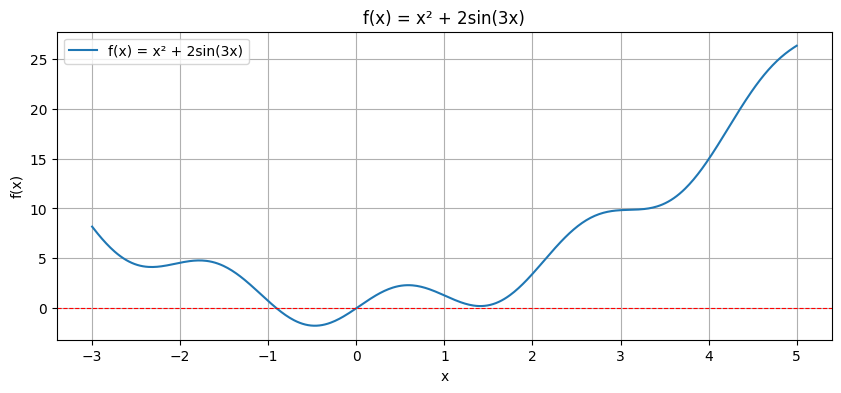


--- Gráficas de los métodos ---


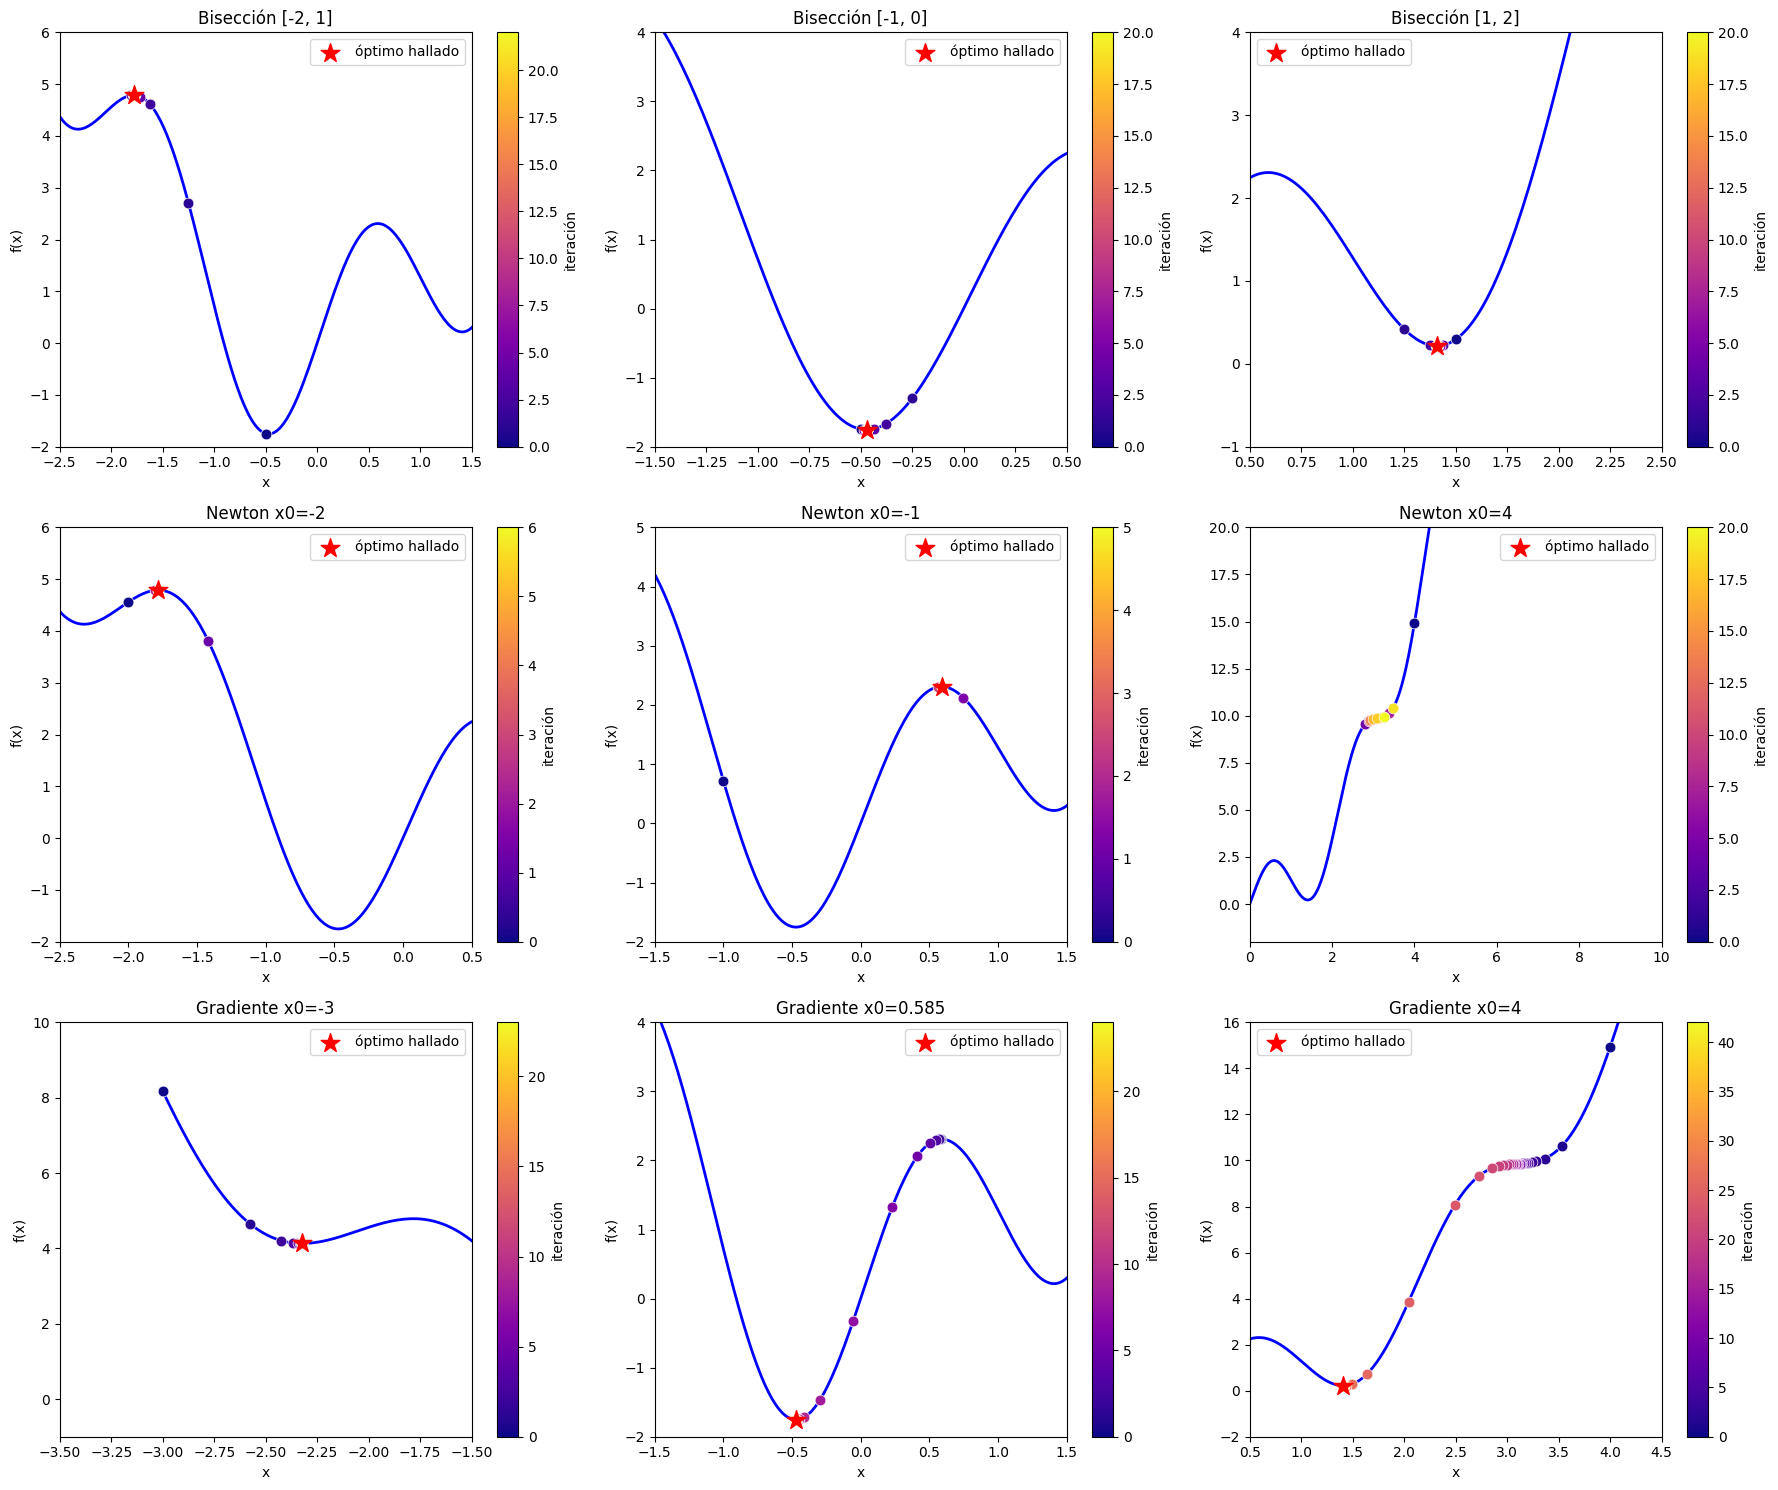

In [119]:
#BONUS graficas
# Grafica de la función
print("\n--- Gráfica de la función ---")

lp = np.linspace(-3, 5, 500)
y_vals = np.array([f.eval(v) for v in lp])

plt.figure(figsize=(10, 4))
plt.plot(lp, y_vals, label="f(x) = x² + 2sin(3x)")
plt.axhline(0, color="red", linestyle="--", linewidth=0.8)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("f(x) = x² + 2sin(3x)")
plt.legend()
plt.grid(True)
plt.show()

print("\n--- Gráficas de los métodos ---")

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
lp = np.linspace(-3, 5, 500)
y_vals = np.array([f.eval(v) for v in lp])

# biseccion
biseccion_configs = [{"a": -2, "b": 1}, {"a": -1, "b": 0}, {"a": 1, "b": 2}]
biseccion_titles = ["Bisección [-2, 1]", "Bisección [-1, 0]", "Bisección [1, 2]"]
biseccion_xlims = [(-2.5, 1.5), (-1.5, 0.5), (0.5, 2.5)]
biseccion_ylims = [(-2, 6), (-2, 4), (-1, 4)]

for j, (params, title, xl, yl) in enumerate(zip(biseccion_configs, biseccion_titles, biseccion_xlims, biseccion_ylims)):
    res, steps, hist = biseccion_route(f, **params)
    ax = axes[0, j]
    ax.plot(lp, y_vals, color="blue", linewidth=2)
    colors = plt.cm.plasma(np.linspace(0, 1, len(hist)))
    for i, xh in enumerate(hist):
        ax.scatter(xh, f.eval(xh), color=colors[i], s=60, zorder=5, edgecolors='white', linewidths=0.5)
    ax.scatter(res, f.eval(res), color="red", s=200, zorder=6, marker="*", label="óptimo hallado")
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend()
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(hist)))
    plt.colorbar(sm, ax=ax, label="iteración")

# newton
newton_configs = [{"x0": -2}, {"x0": -1}, {"x0": 4}]
newton_titles = ["Newton x0=-2", "Newton x0=-1", "Newton x0=4"]
newton_xlims = [(-2.5, 0.5), (-1.5, 1.5), (0, 10)]
newton_ylims = [(-2, 6), (-2, 5), (-2, 20)]

for j, (params, title, xl, yl) in enumerate(zip(newton_configs, newton_titles, newton_xlims, newton_ylims)):
    res, steps, hist = newton_route(f, **params)
    hist_plot = hist[:20]
    ax = axes[1, j]
    ax.plot(lp, y_vals, color="blue", linewidth=2)
    colors = plt.cm.plasma(np.linspace(0, 1, len(hist_plot)))
    for i, xh in enumerate(hist_plot):
        try:
            ax.scatter(xh, f.eval(xh), color=colors[i], s=60, zorder=5, edgecolors='white', linewidths=0.5)
        except:
            pass
    ax.scatter(res, f.eval(res), color="red", s=200, zorder=6, marker="*", label="óptimo hallado")
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend()
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(hist_plot)))
    plt.colorbar(sm, ax=ax, label="iteración")

# gradiente
gradiente_configs = [{"x0": -3, "lr": 0.01}, {"x0": 0.585, "lr": 0.01}, {"x0": 4, "lr": 0.01}]
gradiente_titles = ["Gradiente x0=-3", "Gradiente x0=0.585", "Gradiente x0=4"]
gradiente_xlims = [(-3.5, -1.5), (-1.5, 1.5), (0.5, 4.5)]
gradiente_ylims = [(-1, 10), (-2, 4), (-2, 16)]

for j, (params, title, xl, yl) in enumerate(zip(gradiente_configs, gradiente_titles, gradiente_xlims, gradiente_ylims)):
    res, steps, hist = descenso_gradiente_route(f, **params)
    hist_plot = hist[::5] + [hist[-1]]
    ax = axes[2, j]
    ax.plot(lp, y_vals, color="blue", linewidth=2)
    colors = plt.cm.plasma(np.linspace(0, 1, len(hist_plot)))
    for i, xh in enumerate(hist_plot):
        ax.scatter(xh, f.eval(xh), color=colors[i], s=60, zorder=5, edgecolors='white', linewidths=0.5)
    ax.scatter(res, f.eval(res), color="red", s=200, zorder=6, marker="*", label="óptimo hallado")
    ax.set_xlim(xl)
    ax.set_ylim(yl)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.legend()
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, len(hist_plot)))
    plt.colorbar(sm, ax=ax, label="iteración")

plt.tight_layout()
plt.show()

# Ajuste de datos

In [120]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()



In [121]:
# Genere la función de pérdida L(w)
from abstractions.functions import Const
def lossFunction(model_fn, df):
    xs = df['x'].values
    ys = df['y'].values
    N = len(xs)
    
    total = Const(0)
    for xi, yi in zip(xs, ys):
        pred = model_fn(xi) # ŷ
        error = pred - Const(yi) # ŷ - y
        total = total + error ** 2    # sumatoria (ŷ - y)²
    
    return total * Const(1/N)  #promedio sumatoria (ŷ - y)²

# Recibe un valor xi y devuelven ŷ en funcion de w
def linear_model(xi):
    return w * Const(xi)

def exp_model(xi):
    return exp(w * Const(xi))

def sin_model(xi):
    return sin(w * Const(xi))

loss_linear = lossFunction(linear_model, df_linear)
loss_exp = lossFunction(exp_model, df_exp)
loss_sin = lossFunction(sin_model, df_sin)

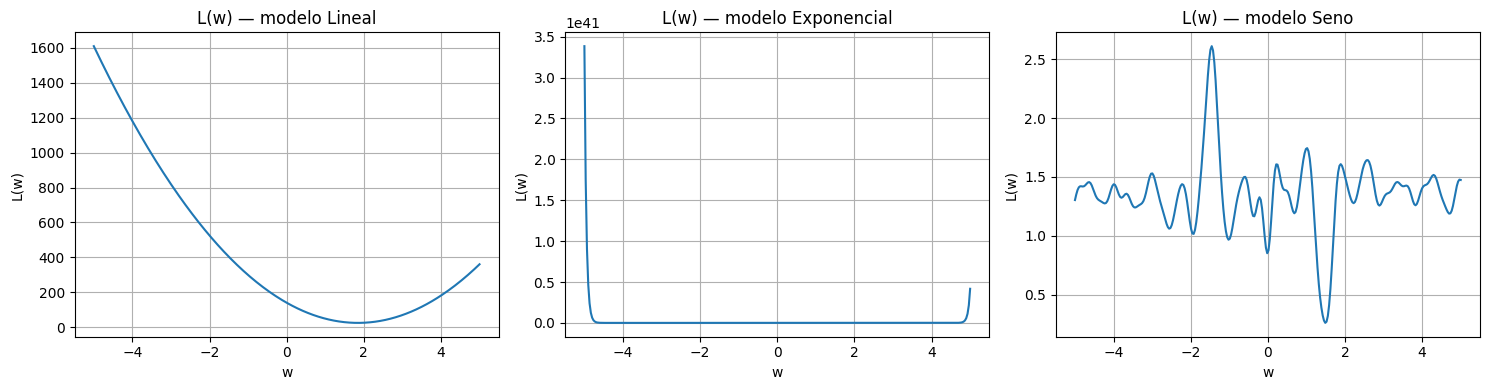

Lineal:      w óptimo = 1.8480 en 268 iteraciones
Exponencial: w óptimo = 0.2126 en 17 iteraciones
Seno:        w óptimo = -0.0107 en 197 iteraciones


In [122]:
# Optimice la función de pérdida
# Graficar L(w) para cada modelo
w_vals = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, L, title in zip(axes, [loss_linear, loss_exp, loss_sin], ["Lineal", "Exponencial", "Seno"]):
    L_vals = np.array([L.eval(wv) for wv in w_vals])
    ax.plot(w_vals, L_vals)
    ax.set_title(f"L(w) — modelo {title}")
    ax.set_xlabel("w")
    ax.set_ylabel("L(w)")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Aplicar descenso por gradiente para encontrar w optimo
w_linear, steps_linear = descenso_gradiente(loss_linear, x0=0.0, lr=0.001)
w_exp, steps_exp = descenso_gradiente(loss_exp,    x0=0.0, lr=0.001)
w_sin, steps_sin = descenso_gradiente(loss_sin,    x0=0.0, lr=0.001)

print(f"Lineal:      w óptimo = {w_linear:.4f} en {steps_linear} iteraciones")
print(f"Exponencial: w óptimo = {w_exp:.4f} en {steps_exp} iteraciones")
print(f"Seno:        w óptimo = {w_sin:.4f} en {steps_sin} iteraciones")

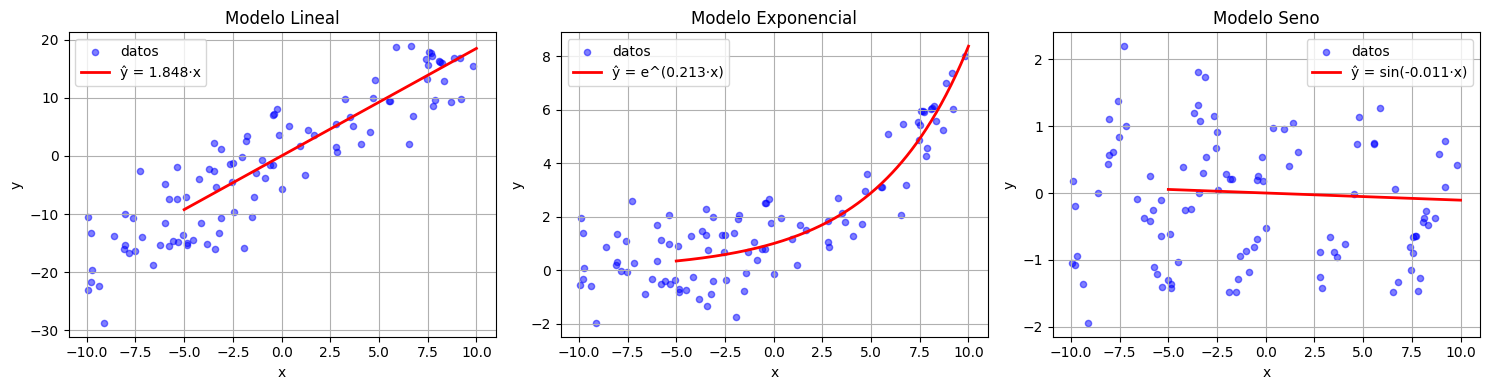

In [123]:
def modelo_lineal(x, w):
    return w * x

def modelo_exp(x, w):
    return np.exp(w * x)

def modelo_sin(x, w):
    return np.sin(w * x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (df_linear, w_linear, modelo_lineal, "Lineal", f"ŷ = {w_linear:.3f}·x"),
    (df_exp,w_exp, modelo_exp, "Exponencial", f"ŷ = e^({w_exp:.3f}·x)"),
    (df_sin, w_sin, modelo_sin, "Seno", f"ŷ = sin({w_sin:.3f}·x)"),
]

x_plot = np.linspace(-5, 10, 300)

for ax, (df, w_opt, model, title, label) in zip(axes, configs):
    ax.scatter(df['x'], df['y'], color='blue', s=20, alpha=0.5, label="datos")
    ax.plot(x_plot, model(x_plot, w_opt), color='red', linewidth=2, label=label)
    ax.set_title(f"Modelo {title}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# BONUS:

# Descenso por gradiente estocástico (SGD):

In [124]:
import random

def sgd(model_fn, df, x0, lr=0.01, tol=1e-6, max_iter=1000):
    xs = df['x'].values
    ys = df['y'].values
    N = len(xs)
    
    wn = x0
    for step in range(max_iter):
        # elegir un punto al azar
        i = random.randint(0, N-1)
        xi = xs[i]
        yi = ys[i]
        
        # construir el error de ese solo punto
        pred  = model_fn(xi)   # ŷ
        error = pred - Const(yi)  # ŷ - y
        li    = error ** 2    # ℓᵢ(w)
        
        # calcular la derivada y dar el paso
        grad = li.derivative().eval(wn)
        wn   = wn - lr * grad
        
        if abs(grad) < tol:
            break
    
    return wn, step + 1


-------------------------------------------------------------------------------
--- Gradiente normal ---
Lineal:      w óptimo = 1.8480 en 268 iteraciones
Exponencial: w óptimo = 0.2126 en 17 iteraciones
Seno:        w óptimo = -0.0107 en 197 iteraciones
-------------------------------------------------------------------------------
--- Descenso por gradiente estocástico (SGD) ---
Lineal:      w óptimo = 1.9871 en 1000 iteraciones
Exponencial: w óptimo = 0.2304 en 1000 iteraciones
Seno:        w óptimo = 0.0274 en 1000 iteraciones
-------------------------------------------------------------------------------


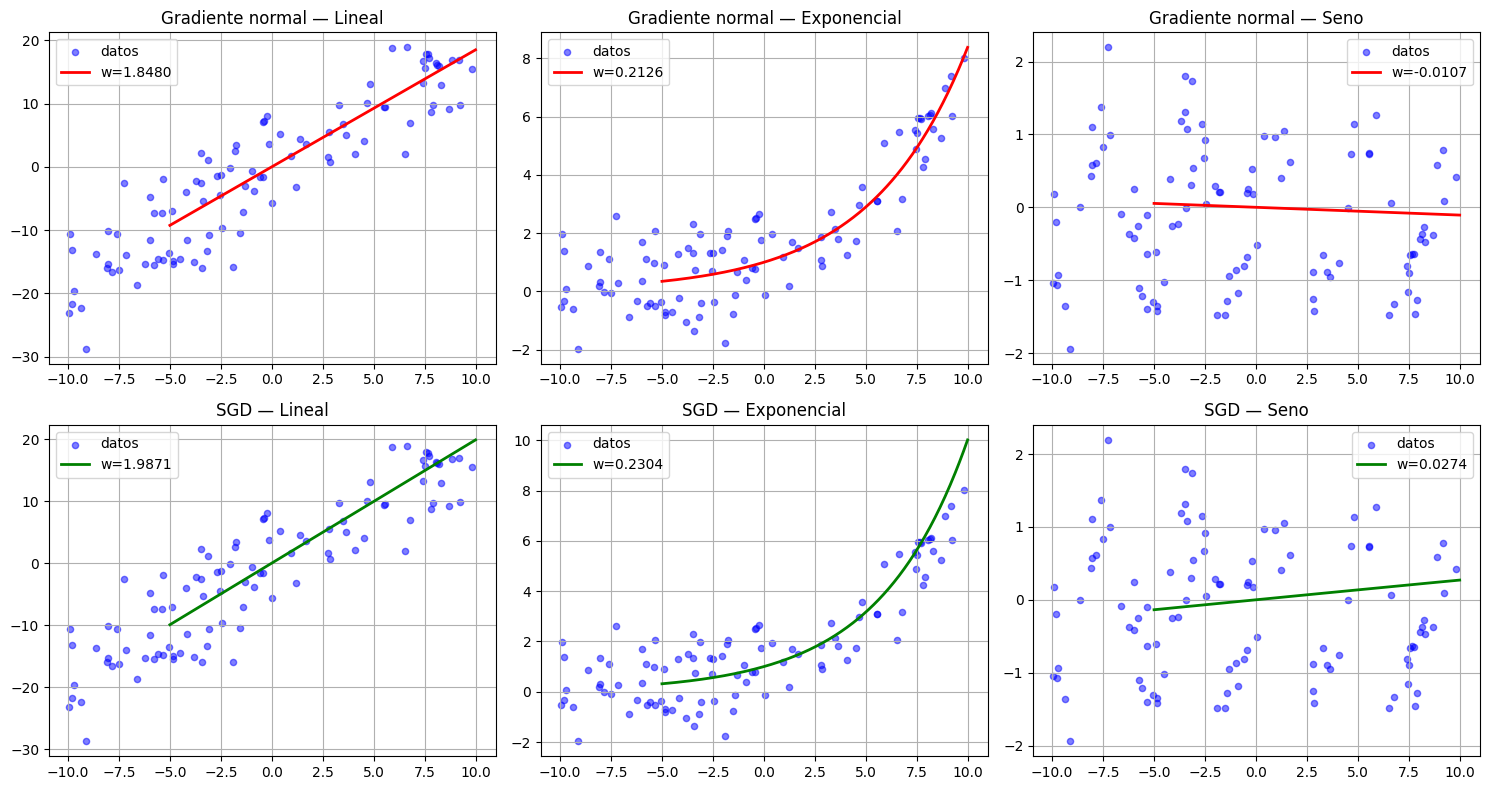

In [125]:
w_sgd_linear, steps_sgd_linear = sgd(linear_model, df_linear, x0=0.0, lr=0.001)
w_sgd_exp,    steps_sgd_exp    = sgd(exp_model,    df_exp,    x0=0.0, lr=0.0001)
w_sgd_sin,    steps_sgd_sin    = sgd(sin_model,    df_sin,    x0=0.0, lr=0.001)

print("\n-------------------------------------------------------------------------------")
print("--- Gradiente normal ---")
print(f"Lineal:      w óptimo = {w_linear:.4f} en {steps_linear} iteraciones")
print(f"Exponencial: w óptimo = {w_exp:.4f} en {steps_exp} iteraciones")
print(f"Seno:        w óptimo = {w_sin:.4f} en {steps_sin} iteraciones")
print("-------------------------------------------------------------------------------")
print("--- Descenso por gradiente estocástico (SGD) ---")
print(f"Lineal:      w óptimo = {w_sgd_linear:.4f} en {steps_sgd_linear} iteraciones")
print(f"Exponencial: w óptimo = {w_sgd_exp:.4f} en {steps_sgd_exp} iteraciones")
print(f"Seno:        w óptimo = {w_sgd_sin:.4f} en {steps_sgd_sin} iteraciones")
print("-------------------------------------------------------------------------------")


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
x_plot = np.linspace(-5, 10, 300)

# fila 1 - gradiente normal
axes[0, 0].scatter(df_linear['x'], df_linear['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[0, 0].plot(x_plot, w_linear * x_plot, color='red', linewidth=2, label=f"w={w_linear:.4f}")
axes[0, 0].set_title("Gradiente normal — Lineal")
axes[0, 0].legend()
axes[0, 0].grid(True)

axes[0, 1].scatter(df_exp['x'], df_exp['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[0, 1].plot(x_plot, np.exp(w_exp * x_plot), color='red', linewidth=2, label=f"w={w_exp:.4f}")
axes[0, 1].set_title("Gradiente normal — Exponencial")
axes[0, 1].legend()
axes[0, 1].grid(True)

axes[0, 2].scatter(df_sin['x'], df_sin['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[0, 2].plot(x_plot, np.sin(w_sin * x_plot), color='red', linewidth=2, label=f"w={w_sin:.4f}")
axes[0, 2].set_title("Gradiente normal — Seno")
axes[0, 2].legend()
axes[0, 2].grid(True)

# fila 2 - SGD
axes[1, 0].scatter(df_linear['x'], df_linear['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[1, 0].plot(x_plot, w_sgd_linear * x_plot, color='green', linewidth=2, label=f"w={w_sgd_linear:.4f}")
axes[1, 0].set_title("SGD — Lineal")
axes[1, 0].legend()
axes[1, 0].grid(True)

axes[1, 1].scatter(df_exp['x'], df_exp['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[1, 1].plot(x_plot, np.exp(w_sgd_exp * x_plot), color='green', linewidth=2, label=f"w={w_sgd_exp:.4f}")
axes[1, 1].set_title("SGD — Exponencial")
axes[1, 1].legend()
axes[1, 1].grid(True)

axes[1, 2].scatter(df_sin['x'], df_sin['y'], color='blue', s=20, alpha=0.5, label="datos")
axes[1, 2].plot(x_plot, np.sin(w_sgd_sin * x_plot), color='green', linewidth=2, label=f"w={w_sgd_sin:.4f}")
axes[1, 2].set_title("SGD — Seno")
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

# Descenso por gradiente con learning rate variable:

In [126]:
def desc_gradiente_lr_variable(f: Function, x0: float, lr0: float, tol: float = 1e-6, max_iter: int = 1000):
    derf = f.derivative()
    
    xn = x0
    for step in range(max_iter):
        lr = lr0 / (1 + step)   # learning rate variable
        grad = derf.eval(xn)
        xn = xn - lr * grad
        
        if abs(grad) < tol:
            break
    
    return xn, step + 1

In [127]:
f = x**2 + 2*sin(3*x)

# lr variable
w_lrv_1, steps_lrv_1 = desc_gradiente_lr_variable(f, x0=-3,    lr0=0.1)
w_lrv_2, steps_lrv_2 = desc_gradiente_lr_variable(f, x0=0.585, lr0=0.1)
w_lrv_3, steps_lrv_3 = desc_gradiente_lr_variable(f, x0=4,     lr0=0.1)

# gradiente normal
w_gn_1, steps_gn_1 = descenso_gradiente(f, x0=-3,    lr=0.01)
w_gn_2, steps_gn_2 = descenso_gradiente(f, x0=0.585, lr=0.01)
w_gn_3, steps_gn_3 = descenso_gradiente(f, x0=4,     lr=0.01)

print("\n-------------------------------------------------------------------------------")
print("--- LR variable ---")
print(f"x0= -3:    x = {w_lrv_1:.4f} en {steps_lrv_1} iteraciones")
print(f"x0= 0.585: x = {w_lrv_2:.4f} en {steps_lrv_2} iteraciones")
print(f"x0= 4:     x = {w_lrv_3:.4f} en {steps_lrv_3} iteraciones")
print("-------------------------------------------------------------------------------")
print("--- Gradiente normal ---")
print(f"x0= -3:    x = {w_gn_1:.4f} en {steps_gn_1} iteraciones")
print(f"x0= 0.585: x = {w_gn_2:.4f} en {steps_gn_2} iteraciones")
print(f"x0= 4:     x = {w_gn_3:.4f} en {steps_gn_3} iteraciones")
print("-------------------------------------------------------------------------------")





-------------------------------------------------------------------------------
--- LR variable ---
x0= -3:    x = -2.3221 en 1000 iteraciones
x0= 0.585: x = -0.4705 en 1000 iteraciones
x0= 4:     x = 1.4080 en 1000 iteraciones
-------------------------------------------------------------------------------
--- Gradiente normal ---
x0= -3:    x = -2.3228 en 109 iteraciones
x0= 0.585: x = -0.4710 en 110 iteraciones
x0= 4:     x = 1.4080 en 203 iteraciones
-------------------------------------------------------------------------------


# Formulación producto de exponenciales vs suma:

In [128]:
def loss_producto(df):
    xs = df['x'].values
    ys = df['y'].values
    
    total = Const(1)
    for xi, yi in zip(xs, ys):
        error = w * Const(xi) - Const(yi)
        term  = exp(-error ** 2)
        total = total * term
    
    return total

L_tilde = loss_producto(df_linear)
neg_L_tilde = Const(-1) * L_tilde

w_tilde, steps_tilde = descenso_gradiente(neg_L_tilde, x0=0.0, lr=0.001)

print(f"L̃(w): w = {w_tilde:.4f} en {steps_tilde} iteraciones")
print(f"L(w): w = {w_linear:.4f} en {steps_linear} iteraciones")

# comparar gradientes en w=0
dL       = loss_linear.derivative()
dL_tilde = neg_L_tilde.derivative()

print(f"\nGradiente L(w=0):  {dL.eval(0.0):.4f}")
print(f"Gradiente L̃(w=0): {dL_tilde.eval(0.0):.6f}")

L̃(w): w = 0.0000 en 1 iteraciones
L(w): w = 1.8480 en 268 iteraciones

Gradiente L(w=0):  -124.8146
Gradiente L̃(w=0): 0.000000


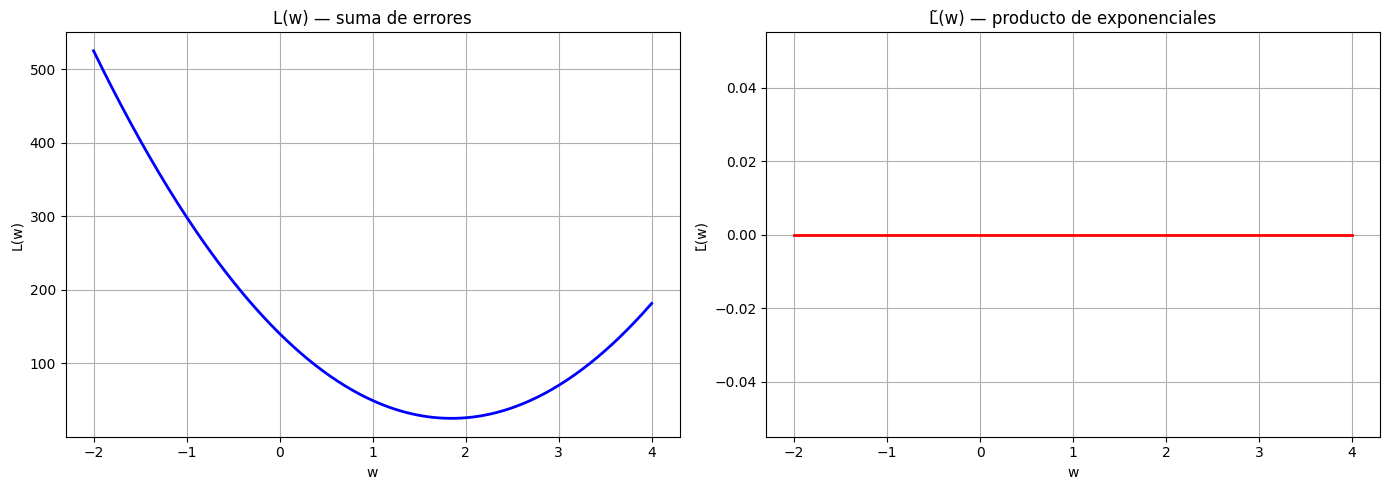

In [129]:
plt.style.use('default')
w_vals = np.linspace(-2, 4, 300)

L_vals       = np.array([loss_linear.eval(wv) for wv in w_vals])
L_tilde_vals = np.array([L_tilde.eval(wv) for wv in w_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(w_vals, L_vals, color="blue", linewidth=2)
axes[0].set_title("L(w) — suma de errores")
axes[0].set_xlabel("w")
axes[0].set_ylabel("L(w)")
axes[0].grid(True)

axes[1].plot(w_vals, L_tilde_vals, color="red", linewidth=2)
axes[1].set_title("L̃(w) — producto de exponenciales")
axes[1].set_xlabel("w")
axes[1].set_ylabel("L̃(w)")
axes[1].grid(True)

plt.tight_layout()
plt.show()